# Formation Flight (Sec 5.6)

Co-design time-varying louver orientations on two cube-shaped satellites to
perform a controlled close approach (docking) using differential SRP.

In [1]:
from pathlib import Path
import jax
import jax.numpy as jnp
import numpy as np
import optax
import matplotlib.pyplot as plt

import nn
import physics
import base
from utils import load_trajectory, sample_moonsun_cubic
import raytracing, estimation, srp_simulation, designer

jax.config.update('jax_enable_x64', True)

OBJECT_NAME = 'lamella/lamella'
DESIGN_NAME = 'louver_rotation_sweep'
FORCE_DATA_PATH = base.get_force_path(OBJECT_NAME, DESIGN_NAME)
ROT_ANGLE_DEG = 90.0
PLOT_DIR = base.PROJECT_ROOT / 'plots' / 'lamella_experiments'
PLOT_DIR.mkdir(parents=True, exist_ok=True)

class SimpleDesign:
    def __init__(self, shape): self.shape = shape
rotation_design = SimpleDesign(shape=6)
designer.my_design = rotation_design

/Users/charlesc/anaconda3/envs/photonsxforce/lib/python3.10/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [2]:
SUN_GRID = (90, 180)
MC_SAMPLES = 10_000
LOAD_PRECOMPUTED = True

force_prefix = str(Path(FORCE_DATA_PATH))

if LOAD_PRECOMPUTED:
    force_flat = np.load(force_prefix + '_force.npy')
    torque_flat = np.load(force_prefix + '_torque.npy')
    dir_flat = np.load(force_prefix + '_directions.npy')
    raw_param_flat = np.load(force_prefix + '_parameters.npy')
    print('Loaded precomputed force/torque maps')
else:
    mesh = raytracing.load_mesh(base.get_mesh_name(OBJECT_NAME))
    rotation_specs = [designer.make_louver_rotation_spec(f'Face_{ax}', max_tilt_rad=jnp.deg2rad(ROT_ANGLE_DEG))
                      for ax in ['PosX', 'NegX', 'PosY', 'NegY', 'PosZ', 'NegZ']]
    design = designer.build_louver_rotation_design(OBJECT_NAME, rotation_specs, max_tilt_rad=jnp.deg2rad(ROT_ANGLE_DEG))
    force, torque, sun_dirs, params = srp_simulation.build_force_map(
        SUN_GRID, MC_SAMPLES, estimation.estimate_backward, mesh, design,
        profile_interval=max(1, MC_SAMPLES // 10))
    force_flat = np.array(force).reshape(-1, 3)
    torque_flat = np.array(torque).reshape(-1, 3)
    dir_flat = np.array(sun_dirs).reshape(-1, 3)
    raw_param_flat = np.array(params).reshape(-1, 6)
    for suffix, arr in [('_force', force_flat), ('_torque', torque_flat),
                        ('_directions', dir_flat), ('_parameters', raw_param_flat)]:
        np.save(force_prefix + suffix + '.npy', arr)
    print('Saved force/torque maps')

Loaded precomputed force/torque maps


In [3]:
LOAD_PRETRAINED = True

nn.train_combined_proxy(
    OBJECT_NAME, DESIGN_NAME, SUN_GRID,
    feature_suffix='_parameters.npy', direction_suffix='_directions.npy',
    force_suffix='_force.npy', torque_suffix='_torque.npy',
    weight_prefix='combined', checkpoint_name='combined_training_checkpoint.pkl',
    load_pretrained=LOAD_PRETRAINED,
    num_hidden_layers=5, hidden_width=192, max_steps=3_000,
    log_every=1000, diag_every=999)

print('NN weights:', base.get_nn_weight_path(OBJECT_NAME, DESIGN_NAME))

NN weights: /Users/charlesc/Documents/GitHub/photonsXforce/data/nn_weights/lamella/lamella_louver_rotation_sweep/


In [4]:
SIM_HOURS = 32.0
STEP_SIZE = 60.0
STEP_COUNT = int(SIM_HOURS * 3600 / STEP_SIZE)
CONTROL_INTERVAL = 15 * 60
CONTROL_COUNT = int(SIM_HOURS * 3600 / CONTROL_INTERVAL) + 1

SC_MASS = 100.0
SC_AREA = 200.0
MOI = jnp.array([1.0, 1.0, 1.0], dtype=jnp.float64)
INITIAL_SEPARATION = 200.0
TARGET_SEPARATION = 5.7
TARGET_VELOCITY = 0.05

trajectory = load_trajectory(base.drive_path + 'trajectories/gps08.csv', limit=None)
t0 = float(trajectory.time[0])
t1 = t0 + SIM_HOURS * 3600
sun_positions = jnp.asarray(trajectory.sun, dtype=jnp.float64)
sun_times = jnp.asarray(trajectory.time, dtype=jnp.float64)
control_times = jnp.asarray(t0 + CONTROL_INTERVAL * jnp.arange(CONTROL_COUNT), dtype=jnp.float64)

pos1_0 = jnp.asarray(trajectory.position[0], dtype=jnp.float64)
vel1_0 = jnp.asarray(trajectory.velocity[0], dtype=jnp.float64)

# Deputy starts 200m ahead in along-track
r_hat = pos1_0 / jnp.linalg.norm(pos1_0)
h_vec = jnp.cross(pos1_0, vel1_0)
c_hat = h_vec / jnp.linalg.norm(h_vec)
l_hat = jnp.cross(c_hat, r_hat)
pos2_0 = pos1_0 + l_hat * INITIAL_SEPARATION

print(f'{SIM_HOURS:.0f}h, {STEP_COUNT} steps, {CONTROL_COUNT} control points')
print(f'Start: {INITIAL_SEPARATION:.0f}m apart, goal: {TARGET_SEPARATION}m at <{TARGET_VELOCITY*1000:.0f}mm/s')

32h, 1920 steps, 129 control points
Start: 200m apart, goal: 5.7m at <50mm/s


In [5]:
def qmul(q1, q2):
    w1, x1, y1, z1 = q1
    w2, x2, y2, z2 = q2
    return jnp.array([
        w1*w2-x1*x2-y1*y2-z1*z2, w1*x2+x1*w2+y1*z2-z1*y2,
        w1*y2-x1*z2+y1*w2+z1*x2, w1*z2+x1*y2-y1*x2+z1*w2])

def qnorm(q): return q / jnp.linalg.norm(q)

def quat_to_rotmat(q):
    w, x, y, z = qnorm(q)
    return jnp.array([
        [1-2*(y*y+z*z), 2*(x*y-w*z), 2*(x*z+w*y)],
        [2*(x*y+w*z), 1-2*(x*x+z*z), 2*(y*z-w*x)],
        [2*(x*z-w*y), 2*(y*z+w*x), 1-2*(x*x+y*y)]])

def qdot(q, omega):
    return 0.5 * qmul(q, jnp.array([0., omega[0], omega[1], omega[2]]))

def rotmat_to_quat(R):
    w = jnp.sqrt(jnp.maximum(0, 1+jnp.trace(R))) / 2
    x = jnp.copysign(jnp.sqrt(jnp.maximum(0, 1+R[0,0]-R[1,1]-R[2,2]))/2, R[2,1]-R[1,2])
    y = jnp.copysign(jnp.sqrt(jnp.maximum(0, 1-R[0,0]+R[1,1]-R[2,2]))/2, R[0,2]-R[2,0])
    z = jnp.copysign(jnp.sqrt(jnp.maximum(0, 1-R[0,0]-R[1,1]+R[2,2]))/2, R[1,0]-R[0,1])
    return jnp.array([w, x, y, z])

# Initial attitude (nadir-pointing)
sun0 = jnp.asarray(trajectory.sun[0], dtype=jnp.float64)
z_sc = -pos1_0 / jnp.linalg.norm(pos1_0)
y_sc = jnp.cross(sun0 / jnp.linalg.norm(sun0), -z_sc)
y_sc = y_sc / jnp.linalg.norm(y_sc)
x_sc = jnp.cross(y_sc, z_sc); x_sc = x_sc / jnp.linalg.norm(x_sc)
q0 = qnorm(rotmat_to_quat(jnp.column_stack([x_sc, y_sc, z_sc])))
omega0 = jnp.zeros(3)

state0_box1 = (pos1_0, vel1_0, q0, omega0)
state0_box2 = (pos2_0, vel1_0.copy(), q0, omega0)

In [6]:
face_count = 6
louver_limits = jnp.full((face_count,), jnp.deg2rad(ROT_ANGLE_DEG), dtype=jnp.float64)

nn_dir = Path(base.get_nn_weight_path(OBJECT_NAME, DESIGN_NAME))
p = nn.load_nn_parameters(nn_dir / 'combined_parameters.bin')
f = nn.load_nn_parameters(nn_dir / 'combined_ray_stats.bin')
t = nn.load_nn_parameters(nn_dir / 'combined_target_stats.bin')
bundle = {
    'params': tuple(jnp.asarray(v, dtype=jnp.float64) for v in p),
    'feat': tuple(jnp.asarray(v, dtype=jnp.float64) for v in f),
    'tgt': tuple(jnp.asarray(v, dtype=jnp.float64) for v in t),
}

def eval_proxy(sun_body, angles):
    feat = jnp.concatenate([sun_body, angles / louver_limits])
    w = nn.whiten_with_stats(feat, bundle['feat'])
    pred = nn.unwhiten(0.5 * (nn.mlp(w, bundle['params']) + 1.0), bundle['tgt'])
    return SC_AREA * pred[:3], pred[3:]

def softsign(x): return x / (1.0 + jnp.abs(x))
def params_to_angles(raw):
    return 0.5 * (softsign(raw) + 1.0) * louver_limits

def build_provider(angle_table, state0_ref):
    def provider(position, time, quat):
        idx = jnp.clip(jnp.searchsorted(control_times, time, side='right') - 1, 0, angle_table.shape[0]-1)
        angles = angle_table[idx]
        sun_pos = sample_moonsun_cubic(time, sun_positions, sun_times)
        R = quat_to_rotmat(quat)
        sun_body = R.T @ ((sun_pos - position) / jnp.maximum(jnp.linalg.norm(sun_pos - position), 1e-12))
        force_body, torque_body = eval_proxy(sun_body, angles)
        return R @ force_body / SC_MASS, torque_body
    return provider

def dynamics(state, time, provider, moi):
    pos, vel, quat, omega = state
    gravity = -3.986004418e14 * pos / jnp.linalg.norm(pos)**3
    srp_acc, torque = provider(pos, time, quat)
    return (vel, gravity + srp_acc, qdot(quat, omega),
            (torque - jnp.cross(omega, moi * omega)) / moi)

def rk4_quat(state, time, f, param, dt, moi):
    def sub(a, b, k):
        s = tuple(si + a*dt*ki for si, ki in zip(state, k))
        return f(s, time + b*dt, param, moi)
    k1 = sub(0, 0, tuple(jnp.zeros_like(s) for s in state))
    k2 = sub(.5, .5, k1); k3 = sub(.5, .5, k2); k4 = sub(1, 1, k3)
    new = tuple(s+(dt/6)*(a+2*b+2*c+d) for s,a,b,c,d in zip(state,k1,k2,k3,k4))
    return (new[0], new[1], qnorm(new[2]), new[3])

def simulate_box(raw_angles, state0):
    provider = build_provider(params_to_angles(raw_angles), state0)
    dt = (t1 - t0) / STEP_COUNT
    def step(carry, t):
        return rk4_quat(carry, t, dynamics, provider, dt, MOI), carry
    final, hist = jax.lax.scan(step, state0, t0 + dt * jnp.arange(STEP_COUNT))
    hist = jax.tree.map(lambda h, f: jnp.concatenate([h, f[None]], axis=0), hist, final)
    return jnp.concatenate([t0 + dt * jnp.arange(STEP_COUNT), jnp.array([t1])]), hist

print(f'Loaded NN proxy ({face_count} louvers per face)')

Loaded NN proxy (6 louvers per face)


In [7]:
def hcl_frame(r, v):
    H = r / jnp.linalg.norm(r)
    C = jnp.cross(r, v); C = C / jnp.linalg.norm(C)
    L = jnp.cross(C, H)
    return H, C, L

def relative_pos_hcl(r1, v1, r2):
    H, C, L = hcl_frame(r1, v1)
    d = r2 - r1
    return jnp.dot(d, H), jnp.dot(d, C), jnp.dot(d, L)

def relative_vel_hcl(r1, v1, r2, v2):
    H, C, L = hcl_frame(r1, v1)
    dv = v2 - v1
    return jnp.dot(dv, H), jnp.dot(dv, C), jnp.dot(dv, L)

In [8]:
def docking_loss(raw_combined, eps=1e-6):
    raw1, raw2 = raw_combined[:, :face_count], raw_combined[:, face_count:]
    _, s1 = simulate_box(raw1, state0_box1)
    _, s2 = simulate_box(raw2, state0_box2)

    H, C, L = relative_pos_hcl(s1[0][-1], s1[1][-1], s2[0][-1])
    vH, vC, vL = relative_vel_hcl(s1[0][-1], s1[1][-1], s2[0][-1], s2[1][-1])

    dist = jnp.sqrt(H**2 + C**2 + L**2 + eps)
    vel = jnp.sqrt(vH**2 + vC**2 + vL**2 + eps)
    dist_err = jnp.abs(dist - TARGET_SEPARATION)

    return 500.0 * (dist_err**2 + 10.0 * dist_err) + 10000.0 * vel**2

In [9]:
N_ITERS = 10  # set to 10_000 for full run

loss_and_grad = jax.jit(jax.value_and_grad(docking_loss))

schedule = optax.cosine_decay_schedule(init_value=0.5, decay_steps=max(N_ITERS, 100), alpha=0.01)
optimizer = optax.chain(optax.clip_by_global_norm(1.0), optax.adam(learning_rate=schedule))

params = jax.random.uniform(jax.random.PRNGKey(123), (CONTROL_COUNT, 2 * face_count),
                            minval=-2.0, maxval=2.0, dtype=jnp.float64)
opt_state = optimizer.init(params)
losses, best_params, best_loss = [], None, float('inf')

for i in range(N_ITERS):
    l, g = loss_and_grad(params)
    losses.append(float(l))
    if float(l) < best_loss:
        best_loss, best_params = float(l), params
    updates, opt_state = optimizer.update(g, opt_state, params)
    params = optax.apply_updates(params, updates)
    if i % max(1, N_ITERS // 10) == 0:
        print(f'iter {i:5d}  loss={l:.4f}')

print(f'Best loss: {best_loss:.4f}')

iter     0  loss=414359704.3251


iter     1  loss=46771629.7601


iter     2  loss=265128491.7434


iter     3  loss=519449737.2455


iter     4  loss=20643036.7105


iter     5  loss=123927625.5186


iter     6  loss=137814327.5782


iter     7  loss=571565913.7836


iter     8  loss=526327177.5152


iter     9  loss=569901406.9184
Best loss: 20643036.7105


In [10]:
_, s1_opt = simulate_box(best_params[:, :face_count], state0_box1)
_, s2_opt = simulate_box(best_params[:, face_count:], state0_box2)

rand_params = jax.random.uniform(jax.random.PRNGKey(0), best_params.shape, minval=-1., maxval=1.)
_, s1_rand = simulate_box(rand_params[:, :face_count], state0_box1)
_, s2_rand = simulate_box(rand_params[:, face_count:], state0_box2)

def hcl_series(s1, s2):
    fn = lambda r1, v1, r2: jnp.array(relative_pos_hcl(r1, v1, r2))
    return jax.vmap(fn)(s1[0], s1[1], s2[0])

hcl_opt = hcl_series(s1_opt, s2_opt)
H_opt, C_opt, L_opt = hcl_opt[:, 0], hcl_opt[:, 1], hcl_opt[:, 2]
hcl_rand = hcl_series(s1_rand, s2_rand)
H_rand, C_rand, L_rand = hcl_rand[:, 0], hcl_rand[:, 1], hcl_rand[:, 2]
t_hours = np.linspace(0, SIM_HOURS, len(H_opt))

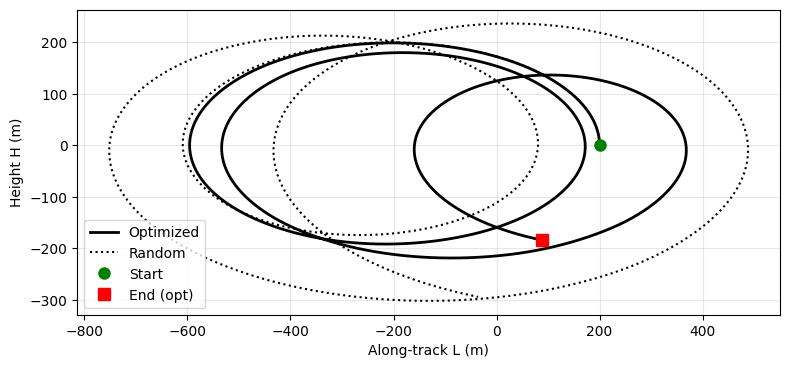

In [11]:
fig, ax = plt.subplots(figsize=(8, 6))
ax.plot(np.asarray(L_opt), np.asarray(H_opt), 'k-', lw=2, label='Optimized')
ax.plot(np.asarray(L_rand), np.asarray(H_rand), 'k:', lw=1.5, label='Random')
ax.plot(float(L_opt[0]), float(H_opt[0]), 'go', ms=8, label='Start')
ax.plot(float(L_opt[-1]), float(H_opt[-1]), 'rs', ms=8, label='End (opt)')
ax.set_xlabel('Along-track L (m)')
ax.set_ylabel('Height H (m)')
ax.legend()
ax.grid(alpha=0.3)
ax.set_aspect('equal')
plt.tight_layout()
plt.savefig(str(PLOT_DIR / 'docking_HL.svg'))
plt.show()

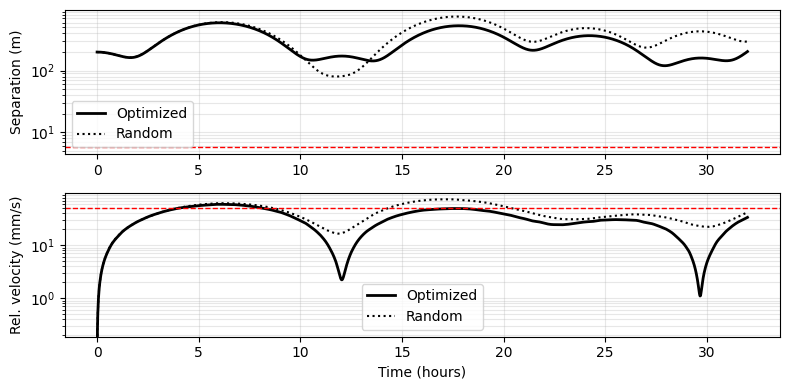

In [12]:
dist_opt = np.sqrt(np.asarray(H_opt)**2 + np.asarray(C_opt)**2 + np.asarray(L_opt)**2)
dist_rand = np.sqrt(np.asarray(H_rand)**2 + np.asarray(C_rand)**2 + np.asarray(L_rand)**2)

def vel_series(s1, s2):
    fn = lambda r1, v1, r2, v2: jnp.array(relative_vel_hcl(r1, v1, r2, v2))
    return jax.vmap(fn)(s1[0], s1[1], s2[0], s2[1])

vel_opt_hcl = vel_series(s1_opt, s2_opt)
vel_opt = np.sqrt(np.sum(np.asarray(vel_opt_hcl)**2, axis=1))
vel_rand_hcl = vel_series(s1_rand, s2_rand)
vel_rand = np.sqrt(np.sum(np.asarray(vel_rand_hcl)**2, axis=1))

fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(8, 4))
ax1.semilogy(t_hours, dist_opt, 'k-', lw=2, label='Optimized')
ax1.semilogy(t_hours, dist_rand, 'k:', lw=1.5, label='Random')
ax1.axhline(TARGET_SEPARATION, color='r', ls='--', lw=1)
ax1.set_ylabel('Separation (m)')
ax1.legend()
ax1.grid(alpha=0.3, which='both')

ax2.semilogy(t_hours, vel_opt * 1000, 'k-', lw=2, label='Optimized')
ax2.semilogy(t_hours, vel_rand * 1000, 'k:', lw=1.5, label='Random')
ax2.axhline(TARGET_VELOCITY * 1000, color='r', ls='--', lw=1)
ax2.set_xlabel('Time (hours)')
ax2.set_ylabel('Rel. velocity (mm/s)')
ax2.legend()
ax2.grid(alpha=0.3, which='both')

plt.tight_layout()
plt.savefig(str(PLOT_DIR / 'docking_distance_velocity.svg'))
plt.show()

/var/folders/nh/9y501_nj2x56h2t3ch9_05f40000gn/T/ipykernel_38295/427696711.py:20: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


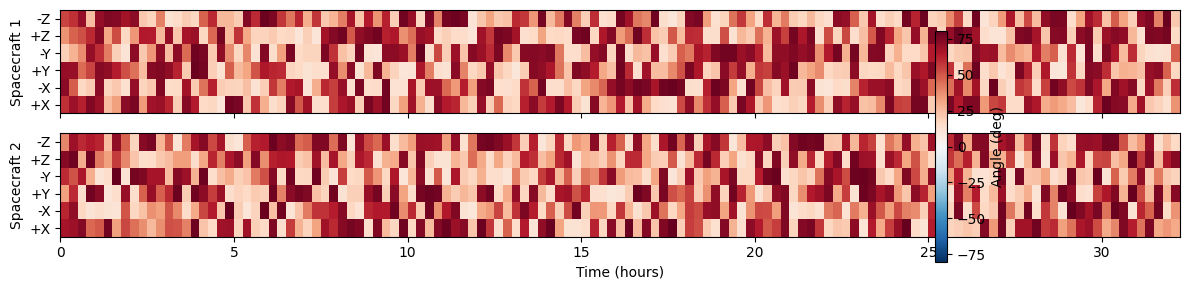

In [13]:
angles1 = np.rad2deg(np.asarray(params_to_angles(best_params[:, :face_count])))
angles2 = np.rad2deg(np.asarray(params_to_angles(best_params[:, face_count:])))
face_names = ['+X', '-X', '+Y', '-Y', '+Z', '-Z']
ctrl_hours = np.arange(CONTROL_COUNT) * CONTROL_INTERVAL / 3600

vmin = min(angles1.min(), angles2.min())
vmax = max(angles1.max(), angles2.max())
dt_h = ctrl_hours[1] - ctrl_hours[0] if len(ctrl_hours) > 1 else 0.25
t_edges = np.concatenate([ctrl_hours, [ctrl_hours[-1] + dt_h]])
f_edges = np.arange(face_count + 1)

fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(12, 3), sharex=True)
for ax, data, title in [(ax1, angles1, 'Spacecraft 1'), (ax2, angles2, 'Spacecraft 2')]:
    im = ax.pcolormesh(t_edges, f_edges, data.T, cmap='RdBu_r', vmin=-vmax, vmax=vmax, shading='flat')
    ax.set_yticks(np.arange(face_count) + 0.5)
    ax.set_yticklabels(face_names)
    ax.set_ylabel(title)
ax2.set_xlabel('Time (hours)')
plt.colorbar(im, ax=[ax1, ax2], label='Angle (deg)')
plt.tight_layout()
plt.savefig(str(PLOT_DIR / 'docking_louver_schedules.svg'))
plt.show()